In [1]:
from OptimalBattery import simulate as sim
import numpy as np
import matplotlib.pyplot as plt
import HierarchBayesParcel.evaluation as ev
import torch as pt
import OptimalBattery.util as ut
from numpy.linalg import eigh
from scipy.stats import pearsonr
from Functional_Fusion.dataset import DataSetMDTB
import PcmPy as pcm
import seaborn as sns
import pickle


No protocol specified


# generate true Us

In [2]:
n_subs = 24
n_parcel = 20
n_voxels  = 40
n_tasks = 16


Us = sim.generate_Us(s= n_subs, k = n_parcel, p = n_voxels, type= 'hard')

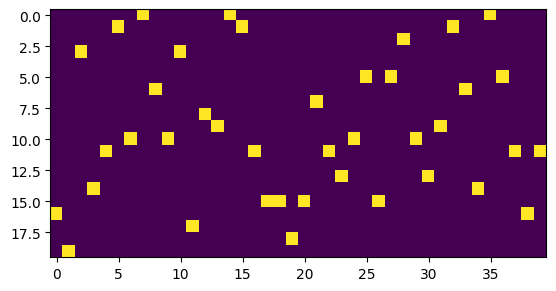

In [3]:
plt.imshow(Us[1])

# Generate Vtrain

In [4]:
# def generate_V(n_tasks, n_parcels, seed=None):
#     if seed is not None:
#         np.random.seed(seed)
#     V = np.zeros((n_tasks, n_parcels))

#     for task in range(n_tasks):
#         if task < 5 and task < n_tasks:
#             # Activate a distinct parcel for each task with strong activation
#             parcel = task % n_parcels  # Ensure parcel index is within bounds
#             V[task, parcel] = 1.0 + np.random.uniform(-0.3, 0.3)  # Add noise

#         elif 5 <= task < 10 and task < n_tasks:
#             # Activate three parcels with decreasing strengths
#             parcel_1 = (task * 3) % n_parcels
#             parcel_2 = (parcel_1 + 3) % n_parcels
#             parcel_3 = (parcel_2 + 3) % n_parcels
#             V[task, [parcel_1, parcel_2, parcel_3]] = [
#                 0.8 + np.random.uniform(-0.3, 0.3),
#                 0.6 + np.random.uniform(-0.3, 0.3),
#                 0.4 + np.random.uniform(-0.3, 0.3)
#             ]
#         else:
#             # Randomly activate five parcels with unique patterns
#             active_parcels = np.random.choice(n_parcels, size=5, replace=False)
#             base_strength = 0.7
#             for i, parcel in enumerate(active_parcels):
#                 V[task, parcel] = base_strength + (0.2 * i) + np.random.uniform(-0.2, 0.2)
#                 base_strength -= 0.1
#     return V

# V = generate_V(n_tasks=20, n_parcels = 16, seed=1)

# # Visualize the V matrix
# plt.imshow(V)




-2.220446049250313e-16
16


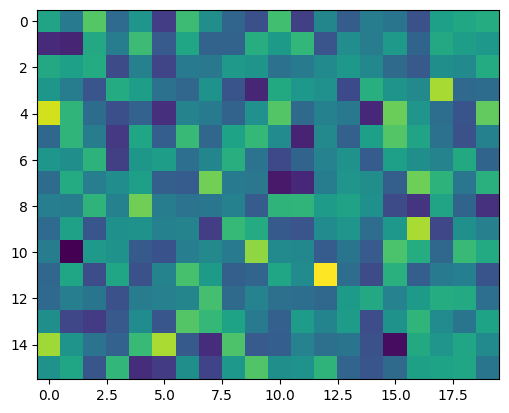

In [5]:
# generate Vs from normal distribution
Vs = np.random.normal(0,1,(n_tasks,n_parcel))

# subtract mean across rows
Vs = Vs - np.mean(Vs, axis=1, keepdims=True)

print(np.sum(Vs[0,:]))
# get the rank
rank = np.linalg.matrix_rank(Vs)
print(rank)

plt.imshow(Vs)


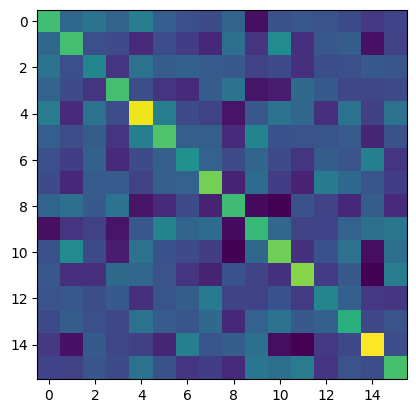

In [6]:
G_rand = Vs @ Vs.T
plt.imshow(G_rand)

# Generate data

In [7]:
# get the data no nooise
y = Vs @ Us

# add noise to data
noise_std = 0.1
noise = np.random.normal(loc=0.0, scale=noise_std, size=y.shape)
y_noisy = y + noise


# Test different methods to estimate Us based on non noisy data

In [8]:
def U_MSE (U_true, U_pred):
    MSE = []
    for subject in range(U_true.shape[0]):
        mse = np.mean((U_true[subject] - U_pred[subject])**2)
        MSE.append(mse)
    return np.mean(MSE)
        


In [9]:
# test different methos
U_hat_ols = sim.estimate_Us_ols(y_noisy, Vs)
U_hat_NNLS = sim.estimate_Us_NNLS(y_noisy, Vs)
U_hat_l1 = sim.estimate_Us_NNLS_lasso(y_noisy, Vs)

In [10]:
OLS_MSE = U_MSE(Us, U_hat_ols)
NNLS_MSE = U_MSE(Us, U_hat_NNLS)
L1_MSE = U_MSE(Us, U_hat_l1)

print(f"OLS MSE: {OLS_MSE}")
print(f"NNLS MSE: {NNLS_MSE}")
print(f"L1 MSE: {L1_MSE}")



OLS MSE: 0.01202699722896212
NNLS MSE: 0.00831486339844061
L1 MSE: 0.0008858043286905227


# Evaluate different lists of V on U_MSE

In [11]:
# make a function that will generate a list 
def evaluate_fixed_task_subset(U_true, Vs, subset_size=8, n_samples=250):
    n_tasks, n_parcels = Vs.shape
    results = {'OLS':[],'NNLS': [], 'L1': [],'L2' : [],'eig_sum':[],'log_det':[],'min_est':[]}

    # Generate fixed-size subsets of tasks
    for _ in range(n_samples):
        print(_)
        # Randomly select a fixed number of tasks
        task_subset_indices = np.random.choice(n_tasks, subset_size, replace=True)
        V_subset = Vs[task_subset_indices, :]
        
        #subtract mean across rows
        V_subset = V_subset - np.mean(V_subset, axis=0)

        G = V_subset @ V_subset.T

        l, _ = eigh(G)
        l = l[::-1]  
        l = l[:-1]  # Remove the last eigenvalue (should be zero after centering)
    
        l[l < 0] = 0  # Remove negative eigenvalues
        results['eig_sum'].append(np.sum(l))
        results['log_det'].append(np.sum(np.log(l + 1e-10)))  # Add small value to avoid log(0)
        results['min_est'].append(np.sum(1 / (l + 1e-10)))

        # generate data
        y_subset =  V_subset @ U_true

        #check rank of V_subset
        rank = np.linalg.matrix_rank(V_subset)

        # Estimate Us for each method
        U_hat_ols = sim.estimate_Us_ols(y_subset, V_subset)
        U_hat_NNLS = sim.estimate_Us_NNLS(y_subset, V_subset)
        U_hat_l1 = sim.estimate_Us_NNLS_lasso(y_subset, V_subset)
        U_hat_l2 = sim.estimate_Us_NNLS_ridge(y_subset, V_subset)

        # Calculate MSE and record
        results['OLS'].append(U_MSE(U_true, U_hat_ols))
        results['NNLS'].append(U_MSE(U_true, U_hat_NNLS))
        results['L1'].append(U_MSE(U_true, U_hat_l1))
        results['L2'].append(U_MSE(U_true, U_hat_l2))

    return results

In [12]:
subset_size = 8  
n_samples = 25

results = evaluate_fixed_task_subset(Us, Vs, subset_size=subset_size, n_samples=n_samples)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24


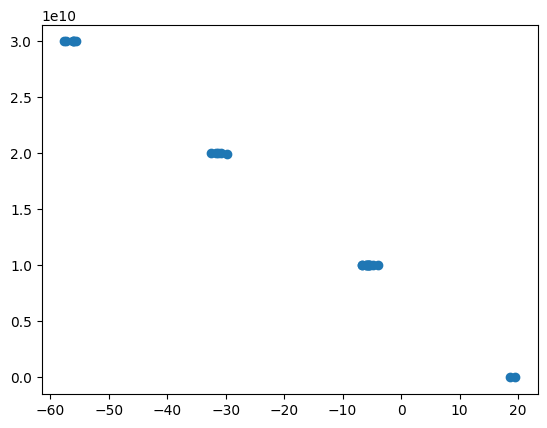

In [13]:
# plot min_est against log_det
plt.scatter(results['log_det'], results['min_est'])

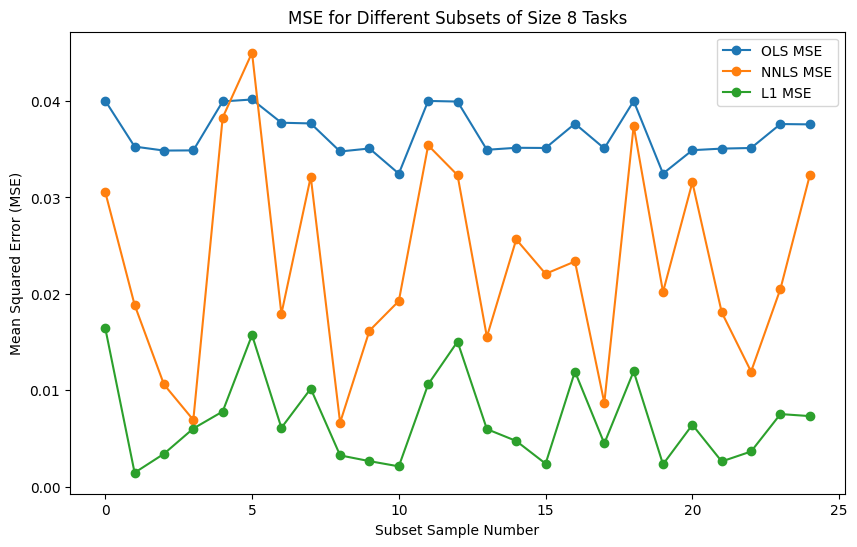

In [14]:
methods = ['OLS', 'NNLS', 'L1']
plt.figure(figsize=(10, 6))

for method in methods:
    if method in results:
        plt.plot(range(n_samples), results[method], 'o-', label=f"{method} MSE")


plt.xlabel('Subset Sample Number')
plt.ylabel('Mean Squared Error (MSE)')
plt.title(f'MSE for Different Subsets of Size {subset_size} Tasks')
plt.legend()
plt.show()

In [15]:
methods = ['OLS', 'NNLS', 'L1']
eigen_metrics = ['eig_sum', 'log_det', 'min_est']
correlations = {metric: {} for metric in eigen_metrics}

for metric in eigen_metrics:
    for method in methods:
        corr, _ = pearsonr(results[metric], results[method])
        correlations[metric][method] = corr
        print(f"Correlation between {metric} and {method} MSE: {corr:.4f}")

Correlation between eig_sum and OLS MSE: -0.5216
Correlation between eig_sum and NNLS MSE: -0.4166
Correlation between eig_sum and L1 MSE: -0.4784
Correlation between log_det and OLS MSE: -0.9980
Correlation between log_det and NNLS MSE: -0.7356
Correlation between log_det and L1 MSE: -0.8721
Correlation between min_est and OLS MSE: 0.9987
Correlation between min_est and NNLS MSE: 0.7345
Correlation between min_est and L1 MSE: 0.8704


# construct Vs with tasks with no correlation

In [16]:
def gram_schmidt(V):
    """ Apply Gram-Schmidt process to matrix V. """
    Q = np.zeros_like(V)
    for i in range(V.shape[0]):
        # Start with the i-th row of A
        q = V[i, :]
        
        # Subtract the projection of q onto the previous rows
        for j in range(0, i):
            q = q - np.dot(Q[j, :], V[i, :]) * Q[j, :]

        # Normalize q to have unit norm
        Q[i, :] = q / np.linalg.norm(q)

    return Q


In [17]:
V_random = np.random.randn(n_tasks, n_parcel)
Vs_orthogonal = gram_schmidt(V_random)
Vs_orthogonal = Vs_orthogonal + np.random.normal(0, 0.01, (n_tasks, n_parcel))


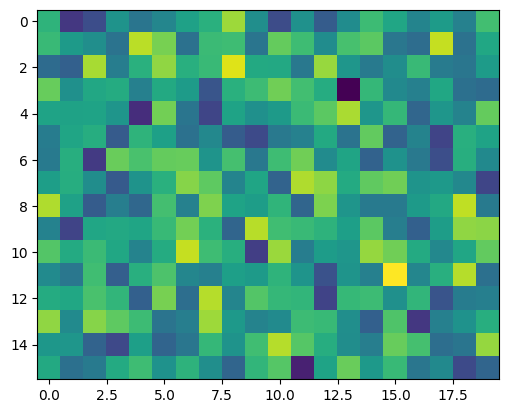

In [18]:
plt.imshow(Vs_orthogonal)

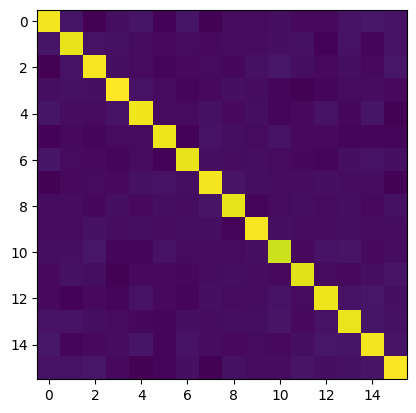

In [19]:
# add diff constants to each row in Vs_orthogonal
G_orthogonal = Vs_orthogonal @ Vs_orthogonal.T
plt.imshow(G_orthogonal)

In [20]:
results = evaluate_fixed_task_subset(Us, Vs_orthogonal, subset_size=subset_size, n_samples=n_samples)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24


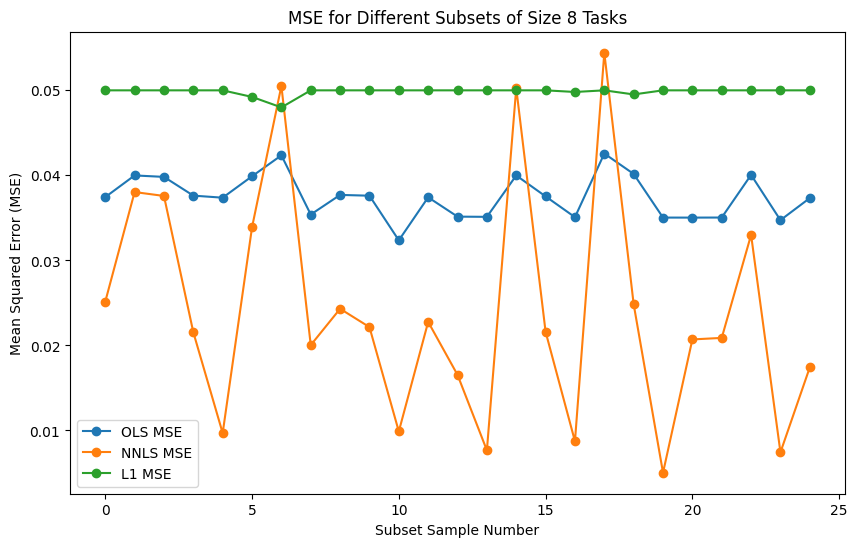

In [21]:
methods = ['OLS', 'NNLS', 'L1']
plt.figure(figsize=(10, 6))

for method in methods:
    if method in results:
        plt.plot(range(n_samples), results[method], 'o-', label=f"{method} MSE")


plt.xlabel('Subset Sample Number')
plt.ylabel('Mean Squared Error (MSE)')
plt.title(f'MSE for Different Subsets of Size {subset_size} Tasks')
plt.legend()
plt.show()

In [22]:
methods = ['OLS','NNLS', 'L1']
eigen_metrics = ['eig_sum', 'log_det', 'min_est']
correlations = {metric: {} for metric in eigen_metrics}

for metric in eigen_metrics:
    for method in methods:
        corr, _ = pearsonr(results[metric], results[method])
        correlations[metric][method] = corr
        print(f"Correlation between {metric} and {method} MSE: {corr:.4f}")

Correlation between eig_sum and OLS MSE: -0.9208
Correlation between eig_sum and NNLS MSE: -0.8772
Correlation between eig_sum and L1 MSE: 0.5183
Correlation between log_det and OLS MSE: -0.9984
Correlation between log_det and NNLS MSE: -0.8735
Correlation between log_det and L1 MSE: 0.4756
Correlation between min_est and OLS MSE: 0.9984
Correlation between min_est and NNLS MSE: 0.8723
Correlation between min_est and L1 MSE: -0.4737


# constrcut Vs with tasks with big correlation

In [23]:
base_pattern = np.random.randn(1, n_parcel) * 10 
Vs_corr = np.tile(base_pattern, (n_tasks, 1)) 
Vs_corr += 0.1 * np.random.randn(n_tasks, n_parcel)

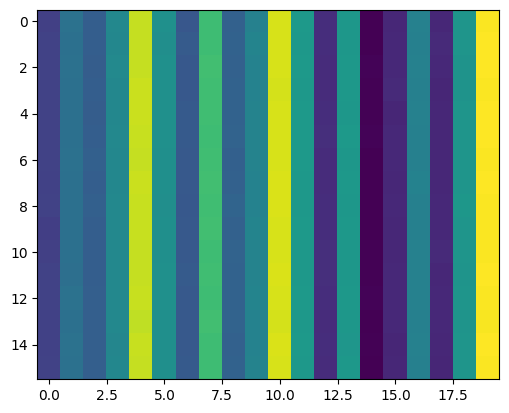

In [24]:
plt.imshow(Vs_corr)

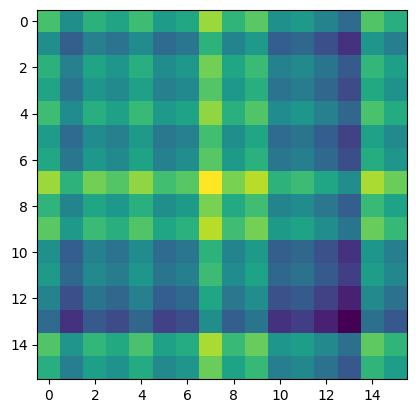

In [25]:
G_corr = Vs_corr @ Vs_corr.T 
plt.imshow(G_corr)


In [26]:
results = evaluate_fixed_task_subset(Us, Vs_corr, subset_size=subset_size, n_samples=n_samples)


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24


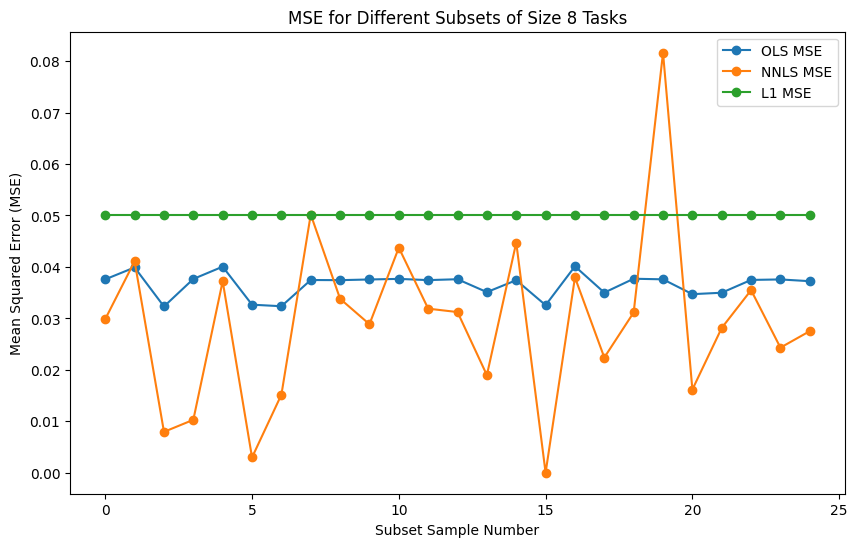

In [27]:
methods = ['OLS', 'NNLS', 'L1']
plt.figure(figsize=(10, 6))

for method in methods:
    if method in results:
        plt.plot(range(n_samples), results[method], 'o-', label=f"{method} MSE")


plt.xlabel('Subset Sample Number')
plt.ylabel('Mean Squared Error (MSE)')
plt.title(f'MSE for Different Subsets of Size {subset_size} Tasks')
plt.legend()
plt.show()

In [28]:
methods = ['OLS','NNLS', 'L1']
eigen_metrics = ['eig_sum', 'log_det', 'min_est']
correlations = {metric: {} for metric in eigen_metrics}

for metric in eigen_metrics:
    for method in methods:
        corr, _ = pearsonr(results[metric], results[method])
        correlations[metric][method] = corr
        print(f"Correlation between {metric} and {method} MSE: {corr:.4f}")

Correlation between eig_sum and OLS MSE: -0.3938
Correlation between eig_sum and NNLS MSE: -0.2424
Correlation between eig_sum and L1 MSE: nan
Correlation between log_det and OLS MSE: -0.9967
Correlation between log_det and NNLS MSE: -0.6547
Correlation between log_det and L1 MSE: nan
Correlation between min_est and OLS MSE: 0.9983
Correlation between min_est and NNLS MSE: 0.6562
Correlation between min_est and L1 MSE: nan


/home/ROBARTS/barafat/.local/lib/python3.8/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


# Load MDTB G matrix

In [29]:
import os
dir = 'Y:/data/FunctionalFusion/MDTB'

if not os.path.exists(dir):
    dir = '/cifs/diedrichsen/data/FunctionalFusion/MDTB'


MDTB_dataset = DataSetMDTB(dir=dir)
data_mdtb_s1,info_mdtb_1  =MDTB_dataset.get_data(space='SUIT3',ses_id='ses-s1',type='CondRun')
data_mdtb_s1[np.isnan(data_mdtb_s1)] = 0


In [30]:
task_names = info_mdtb_1['cond_name'].unique()
print(task_names)

['NoGo' 'Go' 'ToM' 'VideoAct' 'VideoKnots' 'UnpleasantScenes'
 'PleasantScenes' 'Math' 'DigitJudgement' 'CheckerBoard' 'SadFaces'
 'HappyFaces' 'IntervalTiming' 'MotorImagery' 'FingerSimple' 'FingerSeq'
 'Verbal0Back' 'Verbal2Back' 'Object0Back' 'Object2Back'
 'SpatialNavigation' 'StroopIncon' 'StroopCon' 'VerbGen' 'WordRead'
 'VisualSearchSmall' 'VisualSearchMed' 'VisualSearchLarge' 'rest']


In [31]:
cond_vec = np.tile(np.arange(1, 29 + 1), 16)
part_vec = np.repeat(np.arange(1, 16 + 1), 29)

<Axes: >

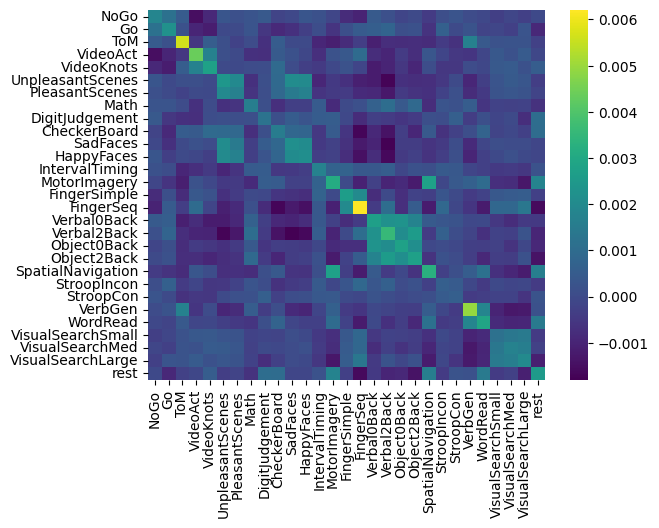

In [32]:
Gs_list = []
E_list = []
for i in range(data_mdtb_s1.shape[0]):
    Gs,E = pcm.util.est_G_crossval(data_mdtb_s1[i], cond_vec, part_vec)
    Gs_list.append(Gs)
    E_list.append(E)

Gs_list = np.stack(Gs_list, 0)
G_individuals_averaged = np.mean(Gs_list, axis=0)

sns.heatmap(G_individuals_averaged, cmap='viridis', xticklabels=task_names, yticklabels=task_names)

tensor(14.9931)


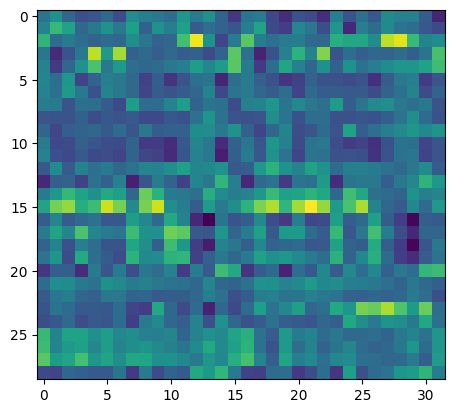

In [33]:
# mdtb vs based on HBP
model_dir = 'Y:/data/Cerebellum/ProbabilisticParcellationModel/Models'
if not os.path.exists(model_dir):
    model_dir = '/cifs/diedrichsen/data/Cerebellum/ProbabilisticParcellationModel/Models'
    
model_name = f'/Models_03/NettekovenSym32_space-MNISymC2'
fname = model_dir + model_name
with open(fname + '.pickle', 'rb') as file:
        full_model = pickle.load(file)[0]

# load emission model & Vs for mdtb ses-1
mdtb_1_emission = full_model.emissions[0]
print(mdtb_1_emission.kappa)
mdtb_1_Vs = mdtb_1_emission.V

# make np array
mdtb_1_Vs = np.array(mdtb_1_Vs)

plt.imshow(mdtb_1_Vs)

In [34]:
from sklearn.decomposition import PCA
from factor_analyzer import Rotator
n_parcels = 20
# Perform PCA
pca = PCA(n_components=n_parcels)
pca.fit(G_individuals_averaged)
V = pca.components_.T  

# Apply Varimax rotation
rotator = Rotator(method='varimax')
V_rotated = rotator.fit_transform(V)

# Compute the new G
G_rotated = V_rotated @ V_rotated.T


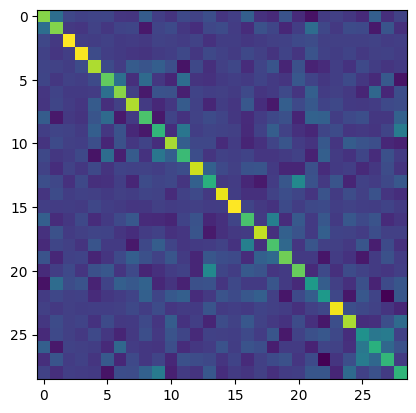

In [35]:
plt.imshow(G_rotated)

In [36]:
subset_size = 8
n_samples = 25

results = evaluate_fixed_task_subset(Us, V_rotated, subset_size=subset_size, n_samples=n_samples)


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24


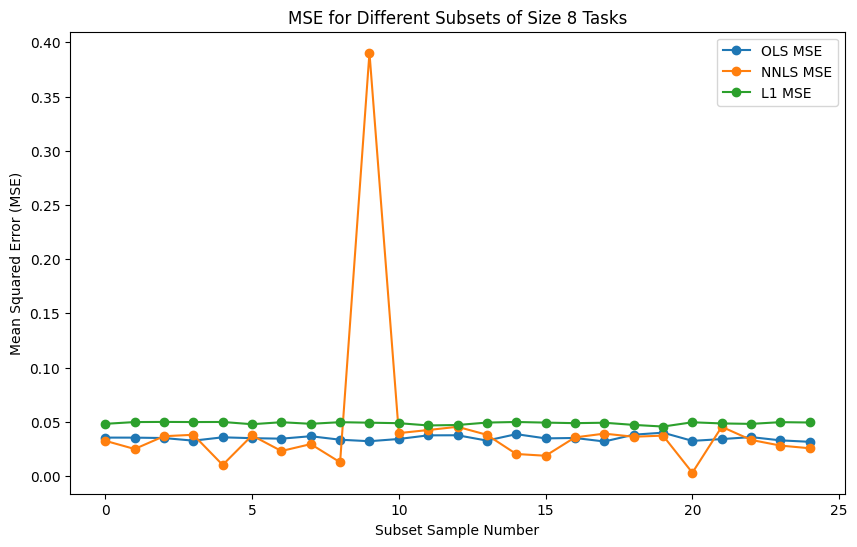

In [37]:
methods = ['OLS', 'NNLS', 'L1']
plt.figure(figsize=(10, 6))

for method in methods:
    if method in results:
        plt.plot(range(n_samples), results[method], 'o-', label=f"{method} MSE")


plt.xlabel('Subset Sample Number')
plt.ylabel('Mean Squared Error (MSE)')
plt.title(f'MSE for Different Subsets of Size {subset_size} Tasks')
plt.legend()
plt.show()

In [38]:
methods = ['OLS','NNLS', 'L1']
eigen_metrics = ['eig_sum', 'log_det', 'min_est']
correlations = {metric: {} for metric in eigen_metrics}

for metric in eigen_metrics:
    for method in methods:
        corr, _ = pearsonr(results[metric], results[method])
        correlations[metric][method] = corr
        print(f"Correlation between {metric} and {method} MSE: {corr:.4f}")

Correlation between eig_sum and OLS MSE: -0.1773
Correlation between eig_sum and NNLS MSE: 0.0663
Correlation between eig_sum and L1 MSE: -0.3736
Correlation between log_det and OLS MSE: -0.9654
Correlation between log_det and NNLS MSE: 0.1909
Correlation between log_det and L1 MSE: 0.7114
Correlation between min_est and OLS MSE: 0.9647
Correlation between min_est and NNLS MSE: -0.1918
Correlation between min_est and L1 MSE: -0.7226
